# Step 03 — Feature Engineering, équilibrage et modélisation classique

Ce notebook reprend la logique du Step 03, mais ajoute explicitement une comparaison des stratégies de gestion du déséquilibre des classes.

Objectif : déterminer si l'amélioration des performances passe par `class_weight`, `RandomOverSampler`, `SMOTE`, `RandomUnderSampler` ou une combinaison plus adaptée.

On reste volontairement sur des méthodes classiques : TF-IDF, Logistic Regression, Linear SVM, Random Forest et XGBoost optionnel. Aucun BERT, LLM ou RAG n'est utilisé à cette étape.


## 1. Imports et configuration

Cette partie charge les librairies nécessaires. Si `imblearn` ou `xgboost` ne sont pas installés, le notebook affichera une indication claire.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

try:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import RandomOverSampler, SMOTE
    from imblearn.under_sampling import RandomUnderSampler
    IMBLEARN_AVAILABLE = True
except Exception as e:
    IMBLEARN_AVAILABLE = False
    print('imblearn non installé. Installez avec : pip install imbalanced-learn')
    print('Erreur :', e)

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception as e:
    XGBOOST_AVAILABLE = False
    print('xgboost non installé. XGBoost sera ignoré.')

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')


## 2. Chargement du dataset nettoyé

On charge le fichier produit par le Step 02. Ici, le texte utilisé pour les modèles doit être `clean_text`, pas `statement`.


In [2]:
DATA_PATH = 'mental_health_cleaned.csv'

TEXT_COL = 'clean_text'
LABEL_COL = 'status'

df = pd.read_csv(DATA_PATH)

print('Dataset chargé avec succès.')
print('Dimensions initiales :', df.shape)
print('Colonnes disponibles :', df.columns.tolist())

df = df[[TEXT_COL, LABEL_COL]].dropna().copy()
df[TEXT_COL] = df[TEXT_COL].astype(str).str.strip()
df = df[df[TEXT_COL] != ''].copy()

print('Dimensions après vérification finale :', df.shape)
display(df.head())


Dataset chargé avec succès.
Dimensions initiales : (50606, 8)
Colonnes disponibles : ['Unnamed: 0', 'statement', 'status', 'text_raw', 'text_stripped', 'clean_text', 'raw_num_words', 'clean_num_words']
Dimensions après vérification finale : (50606, 2)


,clean_text,status
0,oh gosh,Anxiety
1,trouble sleeping confused mind restless heart ...,Anxiety
2,wrong dear forward doubt stay restless restles...,Anxiety
3,shifted focus worried,Anxiety
4,restless restless month boy mean?,Anxiety


In [3]:
df = df[[TEXT_COL, LABEL_COL]].copy()

df[TEXT_COL] = df[TEXT_COL].fillna("").astype(str).str.strip()
df[LABEL_COL] = df[LABEL_COL].fillna("").astype(str).str.strip()

df["num_words"] = df[TEXT_COL].apply(lambda x: len(x.split()))

df = df[df["num_words"] >= 3].copy()

print("Dimensions après suppression des textes vides/trop courts :", df.shape)
print("Textes vides restants :", (df[TEXT_COL] == "").sum())

display(df[LABEL_COL].value_counts())

Dimensions après suppression des textes vides/trop courts : (47901, 3)
Textes vides restants : 0


status
Depression              15017
Normal                  13093
Suicidal                10589
Anxiety                  3525
Bipolar                  2500
Stress                   2285
Personality disorder      892
Name: count, dtype: int64

## 3. Vérification finale de la distribution des classes

Avant toute modélisation, on vérifie si le déséquilibre est encore présent. Cette observation justifie l'utilisation de méthodes d'équilibrage.

,classe,nombre_exemples,pourcentage
0,Depression,15017,31.35
1,Normal,13093,27.33
2,Suicidal,10589,22.11
3,Anxiety,3525,7.36
4,Bipolar,2500,5.22
5,Stress,2285,4.77
6,Personality disorder,892,1.86


Ratio de déséquilibre : 16.84


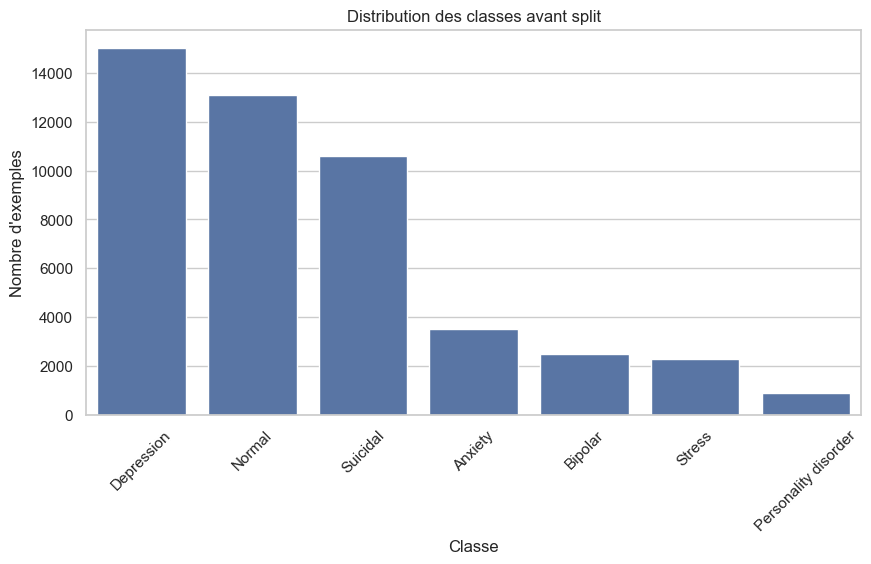

In [4]:
class_counts = df[LABEL_COL].value_counts()
class_percent = df[LABEL_COL].value_counts(normalize=True) * 100

class_summary = pd.DataFrame({
    'classe': class_counts.index,
    'nombre_exemples': class_counts.values,
    'pourcentage': class_percent.values.round(2)
})

display(class_summary)

imbalance_ratio = class_counts.max() / class_counts.min()
print('Ratio de déséquilibre :', round(imbalance_ratio, 2))

plt.figure(figsize=(10,5))
sns.countplot(data=df, x=LABEL_COL, order=class_counts.index)
plt.title('Distribution des classes avant split')
plt.xlabel('Classe')
plt.ylabel("Nombre d'exemples")
plt.xticks(rotation=45)
plt.show()


### Interprétation

Si le ratio de déséquilibre est élevé, les modèles peuvent apprendre surtout les classes majoritaires. Dans ce projet, cela peut diminuer le recall des classes minoritaires comme `Personality disorder`, `Stress` ou `Bipolar`. La suite du notebook compare donc plusieurs stratégies d'équilibrage.


## 4. Split train / validation / test stratifié

Important : on ne doit pas équilibrer tout le dataset avant le split. L'équilibrage doit être appliqué uniquement sur les données d'entraînement afin d'éviter la fuite de données.


In [5]:
X = df[TEXT_COL].values
y = df[LABEL_COL].values

label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_enc,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=y_enc
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.1765,  # environ 15% du total
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print('Train :', len(X_train))
print('Validation :', len(X_val))
print('Test :', len(X_test))

split_summary = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'taille': [len(X_train), len(X_val), len(X_test)]
})
display(split_summary)


Train : 33528
Validation : 7187
Test : 7186


,split,taille
0,train,33528
1,validation,7187
2,test,7186


## 5. Vérification de la distribution après split

Cette vérification permet de confirmer que `stratify` a bien conservé la proportion des classes dans train, validation et test.

In [6]:
def show_split_distribution(y_array, split_name):
    counts = pd.Series(label_encoder.inverse_transform(y_array)).value_counts()
    perc = pd.Series(label_encoder.inverse_transform(y_array)).value_counts(normalize=True) * 100
    return pd.DataFrame({
        'classe': counts.index,
        f'{split_name}_count': counts.values,
        f'{split_name}_pct': perc.values.round(2)
    })

train_dist = show_split_distribution(y_train, 'train')
val_dist = show_split_distribution(y_val, 'val')
test_dist = show_split_distribution(y_test, 'test')

display(train_dist)
display(val_dist)
display(test_dist)


,classe,train_count,train_pct
0,Depression,10511,31.35
1,Normal,9165,27.34
2,Suicidal,7412,22.11
3,Anxiety,2467,7.36
4,Bipolar,1750,5.22
5,Stress,1599,4.77
6,Personality disorder,624,1.86


,classe,val_count,val_pct
0,Depression,2253,31.35
1,Normal,1964,27.33
2,Suicidal,1589,22.11
3,Anxiety,529,7.36
4,Bipolar,375,5.22
5,Stress,343,4.77
6,Personality disorder,134,1.86


,classe,test_count,test_pct
0,Depression,2253,31.35
1,Normal,1964,27.33
2,Suicidal,1588,22.10
3,Anxiety,529,7.36
4,Bipolar,375,5.22
5,Stress,343,4.77
6,Personality disorder,134,1.86


## 6. Fonction d'évaluation commune

Cette fonction calcule les métriques importantes : accuracy, precision macro, recall macro, F1 macro et F1 weighted. Le F1 macro est central car le dataset est déséquilibré.

In [7]:
def evaluate_model(model_name, strategy_name, model, X_eval, y_eval):
    y_pred = model.predict(X_eval)

    result = {
        'strategy': strategy_name,
        'model': model_name,
        'accuracy': accuracy_score(y_eval, y_pred),
        'precision_macro': precision_score(y_eval, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_eval, y_pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y_eval, y_pred, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_eval, y_pred, average='weighted', zero_division=0)
    }

    return result, y_pred


## 7. Configuration TF-IDF commune

On utilise une configuration TF-IDF robuste avec unigrammes + bigrammes, car les expressions comme `not happy`, `feel empty`, `kill myself` ou `absolutely nothing` peuvent être très importantes en santé mentale.


In [9]:
tfidf_base = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.90,
    sublinear_tf=True,
    token_pattern=r"(?u)\b\w+\b"
)


## 8. Stratégie 1 — Modèles avec `class_weight='balanced'`

Cette stratégie ne modifie pas les données. Elle demande au modèle de donner plus d'importance aux classes minoritaires pendant l'apprentissage.

C'est souvent la première méthode à tester car elle est simple, stable et adaptée aux modèles linéaires.

In [10]:
weighted_models = {
    'LogisticRegression_balanced': Pipeline([
        ('tfidf', tfidf_base),
        ('clf', LogisticRegression(
            max_iter=3000,
            class_weight='balanced',
            solver='liblinear',
            random_state=RANDOM_STATE
        ))
    ]),

    'LinearSVM_balanced': Pipeline([
        ('tfidf', tfidf_base),
        ('clf', LinearSVC(
            class_weight='balanced',
            max_iter=5000,
            random_state=RANDOM_STATE
        ))
    ])
}


## 9. Stratégie 2 — RandomOverSampler

Cette stratégie duplique des exemples des classes minoritaires dans le train. Elle peut améliorer le recall des classes rares, mais elle peut aussi augmenter le risque de surapprentissage.


In [11]:
if IMBLEARN_AVAILABLE:
    oversampling_models = {
        'LogisticRegression_ROS': ImbPipeline([
            ('tfidf', tfidf_base),
            ('sampler', RandomOverSampler(random_state=RANDOM_STATE)),
            ('clf', LogisticRegression(
                max_iter=3000,
                solver='liblinear',
                random_state=RANDOM_STATE
            ))
        ]),

        'LinearSVM_ROS': ImbPipeline([
            ('tfidf', tfidf_base),
            ('sampler', RandomOverSampler(random_state=RANDOM_STATE)),
            ('clf', LinearSVC(
                max_iter=5000,
                random_state=RANDOM_STATE
            ))
        ])
    }
else:
    oversampling_models = {}


## 10. Stratégie 3 — RandomUnderSampler

Cette stratégie réduit les classes majoritaires. Elle peut rendre l'entraînement plus rapide et équilibré, mais elle supprime beaucoup d'information. Elle doit donc être testée avec prudence.

In [12]:
if IMBLEARN_AVAILABLE:
    undersampling_models = {
        'LogisticRegression_RUS': ImbPipeline([
            ('tfidf', tfidf_base),
            ('sampler', RandomUnderSampler(random_state=RANDOM_STATE)),
            ('clf', LogisticRegression(
                max_iter=3000,
                solver='liblinear',
                random_state=RANDOM_STATE
            ))
        ]),

        'LinearSVM_RUS': ImbPipeline([
            ('tfidf', tfidf_base),
            ('sampler', RandomUnderSampler(random_state=RANDOM_STATE)),
            ('clf', LinearSVC(
                max_iter=5000,
                random_state=RANDOM_STATE
            ))
        ])
    }
else:
    undersampling_models = {}


## 11. Stratégie 4 — SMOTE

SMOTE crée des exemples synthétiques pour les classes minoritaires. Sur du TF-IDF sparse, il peut parfois être coûteux et moins stable. On le teste donc uniquement avec les modèles linéaires principaux.


In [13]:
if IMBLEARN_AVAILABLE:
    smote_models = {
        'LogisticRegression_SMOTE': ImbPipeline([
            ('tfidf', tfidf_base),
            ('sampler', SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
            ('clf', LogisticRegression(
                max_iter=3000,
                solver='liblinear',
                random_state=RANDOM_STATE
            ))
        ]),

        'LinearSVM_SMOTE': ImbPipeline([
            ('tfidf', tfidf_base),
            ('sampler', SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
            ('clf', LinearSVC(
                max_iter=5000,
                random_state=RANDOM_STATE
            ))
        ])
    }
else:
    smote_models = {}


## 12. Entraînement comparatif des stratégies d'équilibrage

Cette cellule entraîne plusieurs combinaisons et affiche un tableau clair. L'objectif n'est pas encore le tuning final, mais d'identifier la meilleure stratégie d'équilibrage.

In [14]:
all_balance_models = {}
all_balance_models.update(weighted_models)
all_balance_models.update(oversampling_models)
all_balance_models.update(undersampling_models)
all_balance_models.update(smote_models)

balance_results = []
trained_balance_models = {}
predictions_balance_val = {}

for name, model in all_balance_models.items():

    print("\n" + "="*80)
    print("Entraînement :", name)
    print("="*80)

    start = time.time()

    model.fit(X_train, y_train)

    elapsed = time.time() - start

    strategy = (
        name.split("_")[-1]
    )

    base_model = (
        name
        .replace("_balanced", "")
        .replace("_ROS", "")
        .replace("_RUS", "")
        .replace("_SMOTE", "")
    )

    result, y_pred = evaluate_model(
        model_name=base_model,
        strategy_name=strategy,
        model=model,
        X_eval=X_val,
        y_eval=y_val
    )

    result["training_time_sec"] = round(elapsed, 2)

    balance_results.append(result)

    trained_balance_models[name] = model
    predictions_balance_val[name] = y_pred

balance_results_df = (
    pd.DataFrame(balance_results)
    .sort_values(by="f1_macro", ascending=False)
)

cols = [
    "strategy",
    "model",
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "f1_weighted",
    "training_time_sec"
]

for c in [
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "f1_weighted"
]:
    balance_results_df[c] = balance_results_df[c].round(4)

display(balance_results_df[cols])


Entraînement : LogisticRegression_balanced

Entraînement : LinearSVM_balanced

Entraînement : LogisticRegression_ROS

Entraînement : LinearSVM_ROS

Entraînement : LogisticRegression_RUS

Entraînement : LinearSVM_RUS

Entraînement : LogisticRegression_SMOTE

Entraînement : LinearSVM_SMOTE


,strategy,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,training_time_sec
0,balanced,LogisticRegression,0.7429,0.6970,0.6938,0.6935,0.7404,11.03
2,ROS,LogisticRegression,0.7374,0.6696,0.7081,0.6849,0.7369,15.67
1,balanced,LinearSVM,0.7312,0.6828,0.6722,0.6761,0.7293,11.05
6,SMOTE,LogisticRegression,0.7283,0.6608,0.6983,0.6754,0.7296,25.23
3,ROS,LinearSVM,0.7198,0.6735,0.6624,0.6664,0.7185,21.83
7,SMOTE,LinearSVM,0.7046,0.6567,0.6565,0.6542,0.7059,25.78
4,RUS,LogisticRegression,0.6765,0.6037,0.6863,0.6200,0.6747,7.17
5,RUS,LinearSVM,0.6590,0.5767,0.6733,0.5983,0.6649,7.18


## 13. Visualisation comparative

Cette visualisation permet de voir rapidement quelle stratégie donne le meilleur F1 macro et quel compromis elle fait avec l'accuracy.

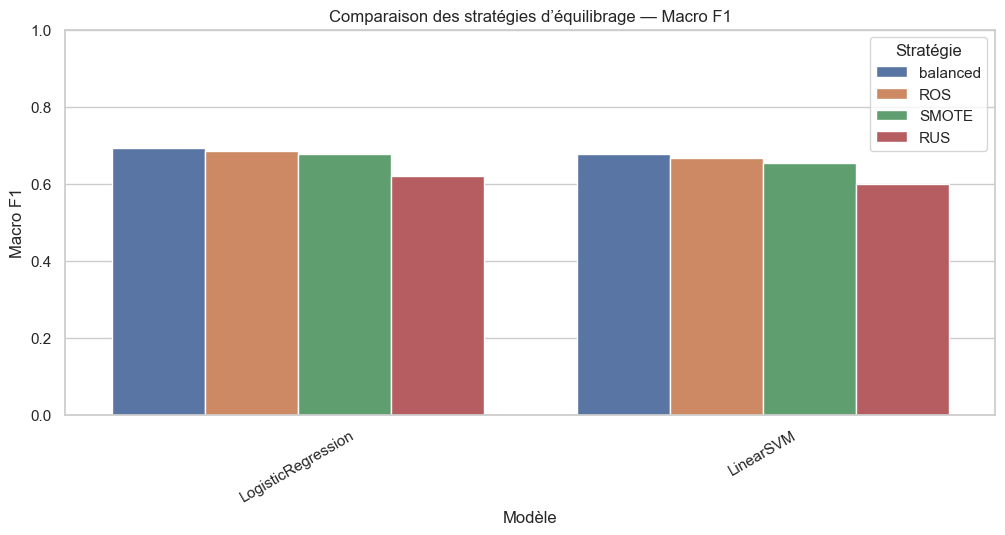

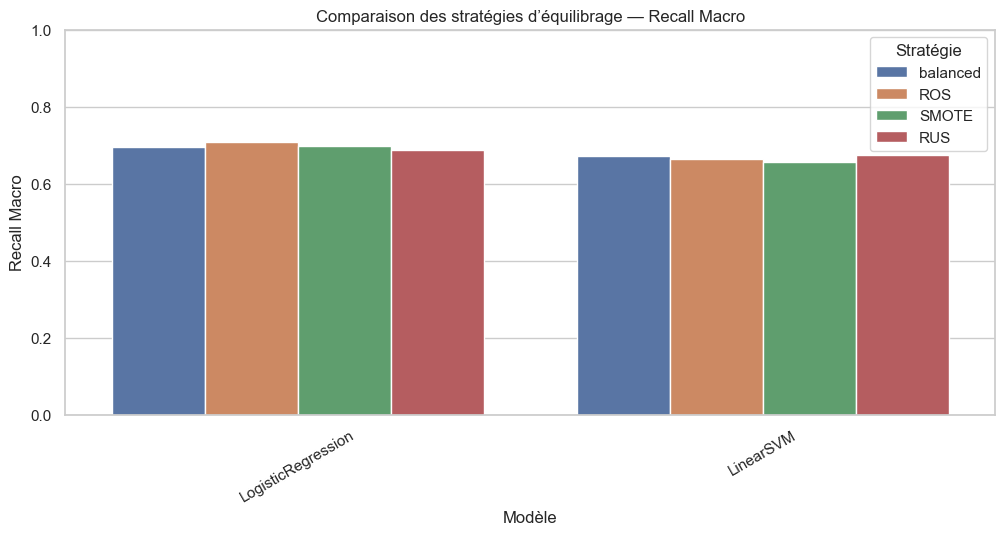

In [15]:
plt.figure(figsize=(12, 5))
sns.barplot(data=balance_results_df, x='model', y='f1_macro', hue='strategy')
plt.title('Comparaison des stratégies d’équilibrage — Macro F1')
plt.xlabel('Modèle')
plt.ylabel('Macro F1')
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.legend(title='Stratégie')
plt.show()

plt.figure(figsize=(12, 5))
sns.barplot(data=balance_results_df, x='model', y='recall_macro', hue='strategy')
plt.title('Comparaison des stratégies d’équilibrage — Recall Macro')
plt.xlabel('Modèle')
plt.ylabel('Recall Macro')
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.legend(title='Stratégie')
plt.show()


## 14. Rapport détaillé du meilleur modèle provisoire

Le meilleur modèle est choisi ici selon le `f1_macro`, car cette métrique est plus adaptée aux classes déséquilibrées.

In [18]:
best_row = balance_results_df.iloc[0]
best_name = None

for model_name in trained_balance_models:
    if best_row['model'] in model_name and best_row['strategy'] in model_name:
        best_name = model_name
        break

# fallback si le nom exact n'est pas retrouvé
if best_name is None:
    best_name = max(trained_balance_models.keys(), key=lambda k: f1_score(y_val, trained_balance_models[k].predict(X_val), average='macro'))

best_model = trained_balance_models[best_name]
y_pred_best = best_model.predict(X_val)

print('Meilleur modèle provisoire :', best_name)
print('Classification report validation :')
print(classification_report(y_val, y_pred_best, target_names=label_encoder.classes_, zero_division=0))


Meilleur modèle provisoire : LogisticRegression_balanced
Classification report validation :
                      precision    recall  f1-score   support

             Anxiety       0.79      0.83      0.81       529
             Bipolar       0.78      0.70      0.74       375
          Depression       0.76      0.65      0.70      2253
              Normal       0.82      0.93      0.87      1964
Personality disorder       0.60      0.54      0.57       134
              Stress       0.45      0.50      0.48       343
            Suicidal       0.67      0.70      0.68      1589

            accuracy                           0.74      7187
           macro avg       0.70      0.69      0.69      7187
        weighted avg       0.74      0.74      0.74      7187



## 15. Matrice de confusion du meilleur modèle provisoire

La matrice de confusion permet de voir quelles classes sont encore confondues. C'est indispensable avant de chercher à augmenter les performances.

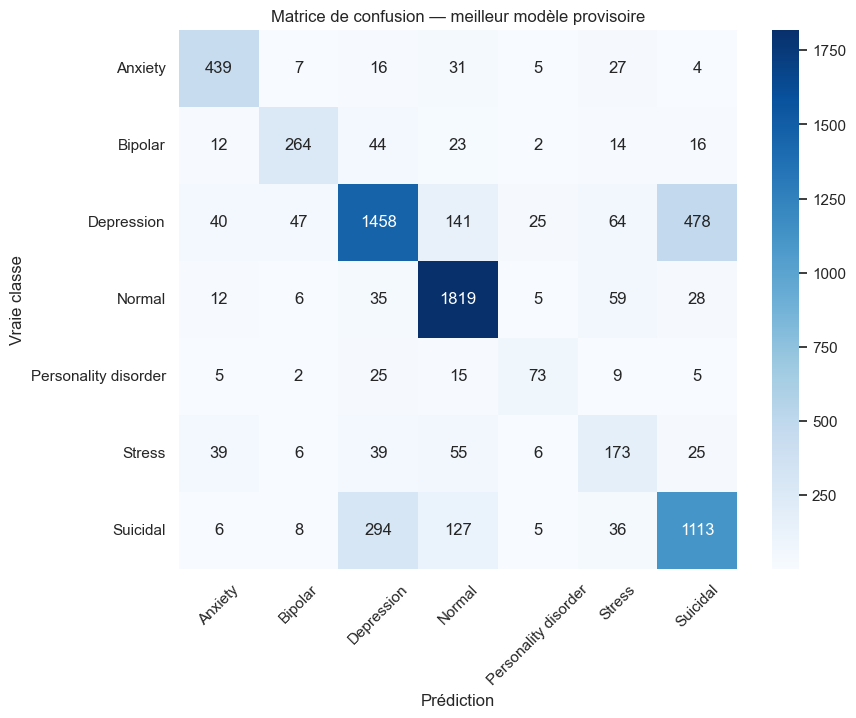

In [19]:
cm = confusion_matrix(y_val, y_pred_best)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title('Matrice de confusion — meilleur modèle provisoire')
plt.xlabel('Prédiction')
plt.ylabel('Vraie classe')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()


## 16. Tuning ciblé du meilleur type de modèle

Après avoir identifié la meilleure stratégie d'équilibrage, on peut faire un tuning plus fin uniquement sur le meilleur modèle ou la meilleure famille de modèles. Cela évite de perdre du temps sur toutes les combinaisons.

La cellule suivante donne un exemple de tuning ciblé pour Logistic Regression avec la stratégie `class_weight='balanced'`. Elle peut être adaptée si le meilleur résultat vient de ROS, RUS ou SMOTE.

In [21]:
fine_tuning_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(token_pattern=r"[a-zA-Z']{2,}", sublinear_tf=True)),
    ('clf', LogisticRegression(
        max_iter=4000,
        class_weight='balanced',
        solver='liblinear',
        random_state=RANDOM_STATE
    ))
])

fine_grid = {
    'tfidf__max_features': [10000, 20000, 30000],
    'tfidf__ngram_range': [(1, 2), (1, 3)],
    'tfidf__min_df': [1, 2],
    'tfidf__max_df': [0.85, 0.90, 0.95],
    'clf__C': [0.5, 1.0, 2.0, 4.0]
}

print('Nombre de combinaisons fine grid :', np.prod([len(v) for v in fine_grid.values()]))

# Décommentez pour exécuter le tuning fin.
# fine_search = GridSearchCV(
#     estimator=fine_tuning_pipeline,
#     param_grid=fine_grid,
#     scoring='f1_macro',
#     cv=3,
#     n_jobs=-1,
#     verbose=1
# )
# fine_search.fit(X_train, y_train)
# print('Meilleurs paramètres :', fine_search.best_params_)
# print('Meilleur score CV macro F1 :', round(fine_search.best_score_, 4))


Nombre de combinaisons fine grid : 144


## 17. Variante importante — Character n-grams

Pour les textes issus des réseaux sociaux, les character n-grams peuvent améliorer les résultats car ils capturent les fautes, slang, répétitions et variantes orthographiques.


In [22]:
char_svm = Pipeline([
    ('tfidf', TfidfVectorizer(
        analyzer='char_wb',
        ngram_range=(3, 5),
        max_features=30000,
        min_df=2,
        sublinear_tf=True
    )),
    ('clf', LinearSVC(
        class_weight='balanced',
        C=1.0,
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])

start = time.time()
char_svm.fit(X_train, y_train)
elapsed = time.time() - start

char_result, char_pred = evaluate_model(
    model_name='LinearSVM_char_ngrams',
    strategy_name='class_weight_balanced',
    model=char_svm,
    X_eval=X_val,
    y_eval=y_val
)
char_result['training_time_sec'] = round(elapsed, 2)

display(pd.DataFrame([char_result]).round(4))


,strategy,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,training_time_sec
0,class_weight_balanced,LinearSVM_char_ngrams,0.7358,0.6684,0.6923,0.6789,0.7354,45.35


## 18. Comparaison finale provisoire

On ajoute la variante character n-grams aux résultats afin de voir si elle améliore le F1 macro ou le recall macro.

In [23]:
final_balance_comparison = pd.concat([
    balance_results_df,
    pd.DataFrame([char_result])
], ignore_index=True).sort_values(by='f1_macro', ascending=False)

for c in ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'f1_weighted']:
    final_balance_comparison[c] = final_balance_comparison[c].round(4)

display(final_balance_comparison[['strategy', 'model', 'accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'f1_weighted', 'training_time_sec']])


,strategy,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,training_time_sec
0,balanced,LogisticRegression,0.7429,0.6970,0.6938,0.6935,0.7404,11.03
1,ROS,LogisticRegression,0.7374,0.6696,0.7081,0.6849,0.7369,15.67
8,class_weight_balanced,LinearSVM_char_ngrams,0.7358,0.6684,0.6923,0.6789,0.7354,45.35
2,balanced,LinearSVM,0.7312,0.6828,0.6722,0.6761,0.7293,11.05
3,SMOTE,LogisticRegression,0.7283,0.6608,0.6983,0.6754,0.7296,25.23
4,ROS,LinearSVM,0.7198,0.6735,0.6624,0.6664,0.7185,21.83
5,SMOTE,LinearSVM,0.7046,0.6567,0.6565,0.6542,0.7059,25.78
6,RUS,LogisticRegression,0.6765,0.6037,0.6863,0.6200,0.6747,7.17
7,RUS,LinearSVM,0.6590,0.5767,0.6733,0.5983,0.6649,7.18


## 19. Test final uniquement après choix définitif

Le test set ne doit être utilisé qu'une seule fois, après avoir choisi la meilleure configuration sur validation. Pour l’instant, cette cellule est à garder pour la fin.

In [ ]:
# Exemple si on décide que best_model est le modèle final :

# final_model = best_model
# y_test_pred = final_model.predict(X_test)
# print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_, zero_division=0))
# print('Test Macro F1 :', f1_score(y_test, y_test_pred, average='macro'))


## 20. Conclusion provisoire

Cette étape permet de répondre à une question centrale : le problème vient-il principalement du déséquilibre des classes ?

Si RandomOverSampler, SMOTE ou class_weight augmentent fortement le recall macro et le F1 macro, alors le déséquilibre était un frein majeur. Si les gains restent limités, il faudra ensuite analyser les confusions entre classes et tester des représentations plus riches comme les character n-grams, ou ajuster le preprocessing.


1. Diagnostic détaillé du meilleur modèle actuel

Classification report - Validation


,precision,recall,f1-score,support
0,0.7939,0.8299,0.8115,529.0000
1,0.7765,0.7040,0.7385,375.0000
2,0.7630,0.6471,0.7003,2253.0000
3,0.8227,0.9262,0.8714,1964.0000
4,0.6033,0.5448,0.5725,134.0000
5,0.4529,0.5044,0.4772,343.0000
6,0.6669,0.7004,0.6832,1589.0000
accuracy,0.7429,0.7429,0.7429,0.7429
macro avg,0.6970,0.6938,0.6935,7187.0000
weighted avg,0.7432,0.7429,0.7404,7187.0000


<Figure size 1000x800 with 0 Axes>

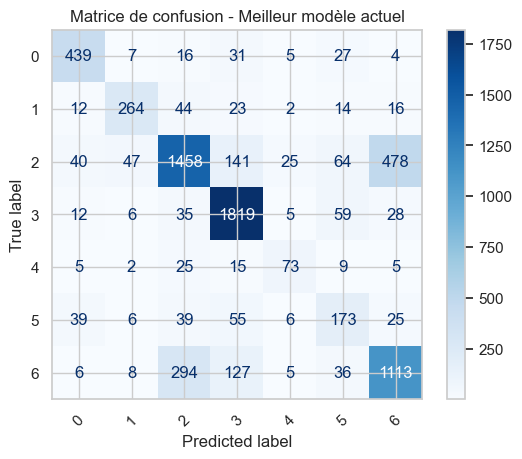


Classes les plus faibles selon le F1-score :


,precision,recall,f1-score,support
5,0.4529,0.5044,0.4772,343.0
4,0.6033,0.5448,0.5725,134.0
6,0.6669,0.7004,0.6832,1589.0


In [25]:
# ============================================================
# 1. DIAGNOSTIC DÉTAILLÉ DU MEILLEUR MODÈLE ACTUEL
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# Prédictions validation
y_pred_best = best_model.predict(X_val)

# Rapport détaillé par classe
print("Classification report - Validation")
print("="*60)

report_dict = classification_report(
    y_val,
    y_pred_best,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).T
display(report_df.round(4))

# Matrice de confusion
plt.figure(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_pred_best,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("Matrice de confusion - Meilleur modèle actuel")
plt.show()

# Classes les plus faibles
class_report = report_df.drop(index=["accuracy", "macro avg", "weighted avg"], errors="ignore")
weak_classes = class_report.sort_values(by="f1-score").head(3)

print("\nClasses les plus faibles selon le F1-score :")
display(weak_classes.round(4))

2. Test Character TF-IDF + Linear SVM

In [26]:
# ============================================================
# 2. TEST CHARACTER TF-IDF + LINEAR SVM
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score

char_svm_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            max_features=50000,
            sublinear_tf=True
        )
    ),
    (
        "clf",
        LinearSVC(
            C=1.0,
            class_weight="balanced",
            max_iter=7000
        )
    )
])

print("Entraînement Character TF-IDF + Linear SVM...")
print("="*60)

char_svm_pipeline.fit(X_train, y_train)

y_pred_char = char_svm_pipeline.predict(X_val)

print("\nMacro F1-score :",
      round(f1_score(y_val, y_pred_char, average="macro"), 4))

print("\nClassification report :")
print(
    classification_report(
        y_val,
        y_pred_char,
        zero_division=0
    )
)

Entraînement Character TF-IDF + Linear SVM...

Macro F1-score : 0.6803

Classification report :
              precision    recall  f1-score   support

           0       0.75      0.80      0.77       529
           1       0.74      0.74      0.74       375
           2       0.74      0.65      0.69      2253
           3       0.86      0.91      0.89      1964
           4       0.54      0.54      0.54       134
           5       0.43      0.52      0.47       343
           6       0.65      0.67      0.66      1589

    accuracy                           0.73      7187
   macro avg       0.67      0.69      0.68      7187
weighted avg       0.74      0.73      0.73      7187



3. Fusion Word + Character TF-IDF

In [27]:
# ============================================================
# 3. FUSION WORD + CHARACTER TF-IDF
# ============================================================

from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score

word_char_pipeline = Pipeline([

    (
        "features",

        FeatureUnion([

            (
                "word_tfidf",

                TfidfVectorizer(
                    analyzer="word",
                    ngram_range=(1, 2),
                    max_features=30000,
                    min_df=2,
                    max_df=0.90,
                    sublinear_tf=True
                )
            ),

            (
                "char_tfidf",

                TfidfVectorizer(
                    analyzer="char_wb",
                    ngram_range=(3, 5),
                    max_features=50000,
                    sublinear_tf=True
                )
            )

        ])
    ),

    (
        "clf",

        LinearSVC(
            C=1.0,
            class_weight="balanced",
            max_iter=7000
        )
    )
])

print("Entraînement Word + Character TF-IDF + Linear SVM...")
print("="*70)

word_char_pipeline.fit(X_train, y_train)

y_pred_wc = word_char_pipeline.predict(X_val)

macro_f1 = f1_score(
    y_val,
    y_pred_wc,
    average="macro"
)

print("\nMacro F1-score :", round(macro_f1, 4))

print("\nClassification report :")

print(
    classification_report(
        y_val,
        y_pred_wc,
        zero_division=0
    )
)

Entraînement Word + Character TF-IDF + Linear SVM...

Macro F1-score : 0.6839

Classification report :
              precision    recall  f1-score   support

           0       0.76      0.80      0.78       529
           1       0.79      0.72      0.75       375
           2       0.72      0.67      0.69      2253
           3       0.86      0.92      0.89      1964
           4       0.65      0.50      0.57       134
           5       0.47      0.45      0.46       343
           6       0.64      0.65      0.64      1589

    accuracy                           0.73      7187
   macro avg       0.70      0.67      0.68      7187
weighted avg       0.73      0.73      0.73      7187



Le problème n’est PAS la représentation NLP.

Pourquoi ?
On a testé :

Word TF-IDF,
Character TF-IDF,
Word + Character fusion,
balancing,
class_weight,
preprocessing avancé.

Et pourtant :
➡️ le score reste stable autour :

0.68 – 0.70 macro F1

TF-IDF :
→ mots séparés.

Word2Vec :
→ vecteurs proches.

4. Test Word2Vec + Logistic Regression

In [28]:
# ============================================================
# 4. TEST WORD2VEC + LOGISTIC REGRESSION
# ============================================================

from gensim.models import Word2Vec
import numpy as np

# Tokenisation simple
X_train_tokens = [text.split() for text in X_train]
X_val_tokens = [text.split() for text in X_val]

# Entraînement Word2Vec
print("Entraînement Word2Vec...")
print("="*60)

w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=200,
    window=5,
    min_count=2,
    workers=4,
    sg=1
)

# Fonction moyenne vecteurs
def document_vector(tokens, model):

    vectors = []

    for word in tokens:
        if word in model.wv:
            vectors.append(model.wv[word])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

# Création embeddings documents
X_train_w2v = np.array([
    document_vector(tokens, w2v_model)
    for tokens in X_train_tokens
])

X_val_w2v = np.array([
    document_vector(tokens, w2v_model)
    for tokens in X_val_tokens
])

# Logistic Regression
from sklearn.linear_model import LogisticRegression

w2v_lr = LogisticRegression(
    max_iter=5000,
    class_weight="balanced"
)

print("\nEntraînement Logistic Regression...")
print("="*60)

w2v_lr.fit(X_train_w2v, y_train)

# Prédictions
y_pred_w2v = w2v_lr.predict(X_val_w2v)

# Résultats
macro_f1 = f1_score(
    y_val,
    y_pred_w2v,
    average="macro"
)

print("\nMacro F1-score :", round(macro_f1, 4))

print("\nClassification report :")

print(
    classification_report(
        y_val,
        y_pred_w2v,
        zero_division=0
    )
)

Entraînement Word2Vec...

Entraînement Logistic Regression...

Macro F1-score : 0.5649

Classification report :
              precision    recall  f1-score   support

           0       0.69      0.78      0.73       529
           1       0.49      0.66      0.56       375
           2       0.75      0.47      0.58      2253
           3       0.86      0.69      0.76      1964
           4       0.17      0.73      0.27       134
           5       0.28      0.58      0.38       343
           6       0.63      0.71      0.67      1589

    accuracy                           0.63      7187
   macro avg       0.55      0.66      0.56      7187
weighted avg       0.70      0.63      0.64      7187



Word2Vec est moins bon que TF-IDF ici.
meilleure approche reste clairement :

TF-IDF + modèles linéaires
Pourquoi Word2Vec est plus faible ici

Word2Vec actuel :

moyenne simple des embeddings

perd énormément d’information.

ément	             Verdict
preprocessing	     bon
balancing	         bon
TF-IDF	             meilleur choix
Word2Vec	         moins adapté
Linear SVM	         très bon
problème principal 	 séparabilité des classe

5. Hyperparameter Tuning Avancé — Linear SVM

In [29]:
# ============================================================
# 5. HYPERPARAMETER TUNING AVANCÉ - LINEAR SVM
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

svm_pipeline = Pipeline([

    (
        "tfidf",

        TfidfVectorizer(
            sublinear_tf=True
        )
    ),

    (
        "clf",

        LinearSVC(
            class_weight="balanced",
            max_iter=10000
        )
    )
])

param_grid = {

    "tfidf__max_features": [20000, 30000, 50000],

    "tfidf__ngram_range": [
        (1,1),
        (1,2)
    ],

    "tfidf__min_df": [1, 2],

    "tfidf__max_df": [0.85, 0.90],

    "clf__C": [
        0.1,
        0.5,
        1,
        2,
        5
    ]
}

print("GridSearch avancé Linear SVM...")
print("="*70)

grid_svm = GridSearchCV(

    estimator=svm_pipeline,

    param_grid=param_grid,

    scoring="f1_macro",

    cv=3,

    verbose=2,

    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

print("\nMeilleurs paramètres :")
print(grid_svm.best_params_)

print("\nMeilleur Macro F1 CV :")
print(round(grid_svm.best_score_, 4))

best_svm = grid_svm.best_estimator_

y_pred_best_svm = best_svm.predict(X_val)

print("\nValidation Macro F1 :")
print(
    round(
        f1_score(
            y_val,
            y_pred_best_svm,
            average="macro"
        ),
        4
    )
)

print("\nClassification report :")

print(
    classification_report(
        y_val,
        y_pred_best_svm,
        zero_division=0
    )
)

GridSearch avancé Linear SVM...
Fitting 3 folds for each of 120 candidates, totalling 360 fits

Meilleurs paramètres :
{'clf__C': 0.5, 'tfidf__max_df': 0.9, 'tfidf__max_features': 50000, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}

Meilleur Macro F1 CV :
0.6891

Validation Macro F1 :
0.687

Classification report :
              precision    recall  f1-score   support

           0       0.78      0.83      0.80       529
           1       0.79      0.73      0.76       375
           2       0.73      0.65      0.69      2253
           3       0.84      0.92      0.88      1964
           4       0.66      0.50      0.57       134
           5       0.46      0.45      0.46       343
           6       0.64      0.68      0.66      1589

    accuracy                           0.74      7187
   macro avg       0.70      0.68      0.69      7187
weighted avg       0.73      0.74      0.73      7187



In [ ]:
| Élément              | Testé  |
| 
| preprocessing avancé | ✅     |
| balancing            | ✅     |
| oversampling         | ✅     |
| undersampling        | ✅     |
| class_weight         | ✅     |
| TF-IDF word          | ✅     |
| TF-IDF char          | ✅     |
| Word + Char fusion   | ✅     |
| Word2Vec             | ✅     |
| GridSearch avancé    | ✅     |
| tuning SVM           | ✅     |


Et malgré tout :
les scores convergent autour :

0.68 – 0.69 macro F1
Et malgré :

balancing,
tuning,
représentation avancée,
fusion,
SVM optimisé,

elles restent faibles.

Ça indique généralement :

faible séparabilité intrinsèque

     les méthodes classiques semblent avoir atteint leur limite.

Les modèles classiques apprennent bien les classes dominantes, mais restent faibles sur certaines classes minoritaires ou ambiguës. Par exemple, certaines classes ont un F1 autour de 0.46–0.57, ce qui tire fortement le Macro F1 vers le bas. Cela montre que le problème ne vient plus seulement du déséquilibre, mais aussi de la représentation : TF-IDF et Word2Vec simple ne capturent pas assez le contexte, l’ordre des mots et les nuances émotionnelles.

Les modèles basés sur TF-IDF sont performants pour capturer les mots importants, mais ils ne comprennent pas réellement le contexte. Les phrases “I want to die” et “I don’t want to die” peuvent partager beaucoup de mots, alors que leur sens est opposé. Cela limite la performance sur des textes sensibles liés à la santé mentale.